# Notebook 3 — 2D Consolidation FEM Verification

This notebook runs the 2D FEM consolidation solver and checks it against the analytical Boussinesq initial condition.

Checks:

1. **Initial pore-pressure check** — FEM u₀ at every mesh node must match the analytical Boussinesq u₀ field. Maximum and RMS differences are reported.
2. **Pore-pressure contour plots** — visual inspection at t = 0 and a mid-time snapshot.
3. **Surface settlement profile** — settlement across the surface width at several times.

A single uniform layer is used here to keep the first verification as simple as possible. Layered examples follow at the end.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

import os, sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

from src.geotech_consolidation.models.terzaghi_2d.fem import Get_terzaghi2D_FEA


H = 5.0        
W = H           
nx  = 25           
load = 100.0        # kPa
base  = 2.0     
final_time          = 3650 * 24 * 60 * 60   # 10 years total time (s)
time_steps = 500

Cv_val     = 2e-7         # coefficient of consolidation (m²/s)
Mv_val     = 5e-4         # coefficient of volume compressibility (m²/kN)

time_days  = np.linspace(0, final_time / (60 * 60 * 24), time_steps)

# --- Permeability from Cv ---
# k = Cv * Mv * γw
gamma_w = 9.81   # unit weight of water (kN/m³)
k = Cv_val * Mv_val * gamma_w
print(f"Cv = {Cv_val:.2e} m²/s")
print(f"k  = {k:.2e} m/s   (k = Cv · Mv · γw)")

Cv = 2.00e-07 m²/s
k  = 9.81e-10 m/s   (k = Cv · Mv · γw)


## FEM Solve


In [2]:
settlement_surface, total_settlement, u_hist, unique_X, node_X, node_Y = Get_terzaghi2D_FEA(
    H=H, W=W, nx=nx, load=load,
    final_time=final_time, time_steps=time_steps,
    Cv=Cv_val, Mv=Mv_val,
    base=base, depths=None
)

print(f"u_hist shape:          {u_hist.shape}   (time_steps × n_nodes)")
print(f"settlement_surface:    {settlement_surface.shape}  (time_steps × nX)")
print(f"unique_X range:        [{unique_X.min():.1f}, {unique_X.max():.1f}] m")
print(f"Max pore pressure:     {u_hist.max():.2f} kPa")
print(f"Max settlement:        {settlement_surface.max() * 1000:.2f} mm")

u_hist shape:          (500, 676)   (time_steps × n_nodes)
settlement_surface:    (500, 26)  (time_steps × nX)
unique_X range:        [-5.0, 5.0] m
Max pore pressure:     99.60 kPa
Max settlement:        128.85 mm


## Initial Pore-Pressure Check — FEM vs Analytical Boussinesq u₀

The FEM sets its initial condition by interpolating the analytical Boussinesq formula onto the mesh. The check below confirms the interpolation is exact (errors should be at machine-precision level) and compares the maximum values.

Boussinesq initial condition:

```
u₀(x, z) = (q/π) · [ arctan((x+B)/z) − arctan((x−B)/z)
                     + z·((x+B)/((x+B)²+z²) − (x−B)/((x−B)²+z²)) ]
```

where B = base/2 and z is the depth (positive downward).


=== Initial pore-pressure check ===
  FEM maximum u₀:        99.5967 kPa
  Analytical maximum u₀: 99.5967 kPa
  Max |error|:           0.0000 kPa
  RMS error:             0.0000 kPa


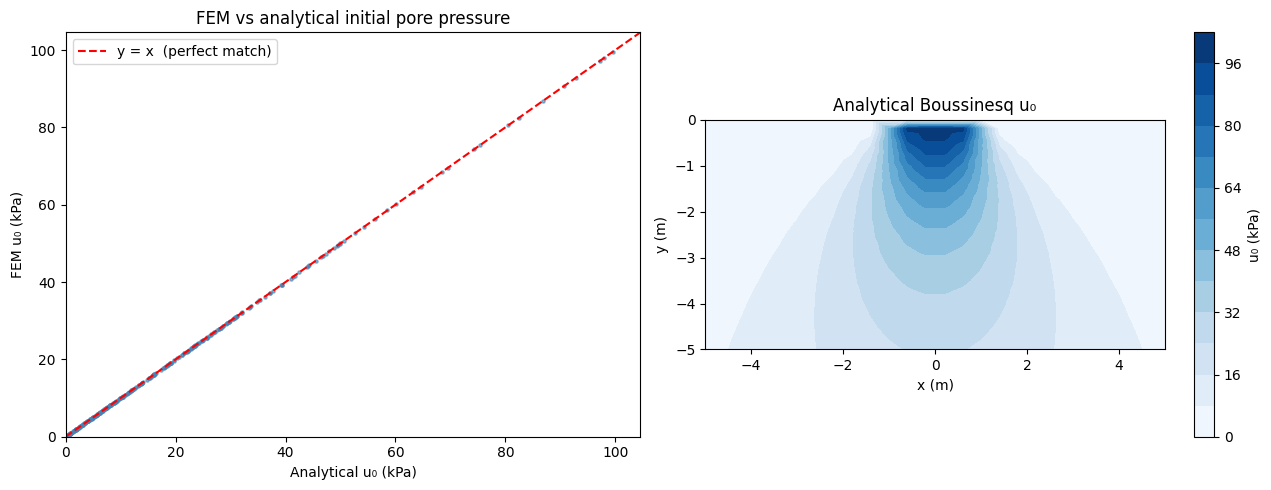

In [3]:
# Analytical Boussinesq u0 at every mesh node
B      = base / 2.0
eps    = 1e-12
X_node = node_X
Z_node = np.maximum(-node_Y, eps)   # depth, positive downward

term1  = np.arctan((X_node + B) / Z_node) - np.arctan((X_node - B) / Z_node)
term2  = Z_node * (
    (X_node + B) / ((X_node + B)**2 + Z_node**2) -
    (X_node - B) / ((X_node - B)**2 + Z_node**2)
)
u0_analytical          = (load / np.pi) * (term1 + term2)
u0_analytical[np.isclose(node_Y, 0.0)] = 0.0   # drained surface BC

u0_fem = u_hist[0, :]
error  = u0_fem - u0_analytical

print("=== Initial pore-pressure check ===")
print(f"  FEM maximum u₀:        {u0_fem.max():.4f} kPa")
print(f"  Analytical maximum u₀: {u0_analytical.max():.4f} kPa")
print(f"  Max |error|:           {np.abs(error).max():.4f} kPa")
print(f"  RMS error:             {np.sqrt(np.mean(error**2)):.4f} kPa")

# Scatter: FEM vs analytical at every node
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = max(u0_analytical.max(), u0_fem.max()) * 1.05
axes[0].scatter(u0_analytical, u0_fem, s=5, alpha=0.35, color="steelblue")
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1.5, label="y = x  (perfect match)")
axes[0].set_xlabel("Analytical u₀ (kPa)")
axes[0].set_ylabel("FEM u₀ (kPa)")
axes[0].set_title("FEM vs analytical initial pore pressure")
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].legend()

# Contour of analytical u0
triang = tri.Triangulation(node_X, node_Y)
cf = axes[1].tricontourf(triang, u0_analytical, levels=15, cmap="Blues")
plt.colorbar(cf, ax=axes[1], label="u₀ (kPa)")
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("y (m)")
axes[1].set_title("Analytical Boussinesq u₀")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## Pore-Pressure Contours Through Time

Contour plots at t = 0 and a mid-time snapshot confirm the field is dissipating physically.


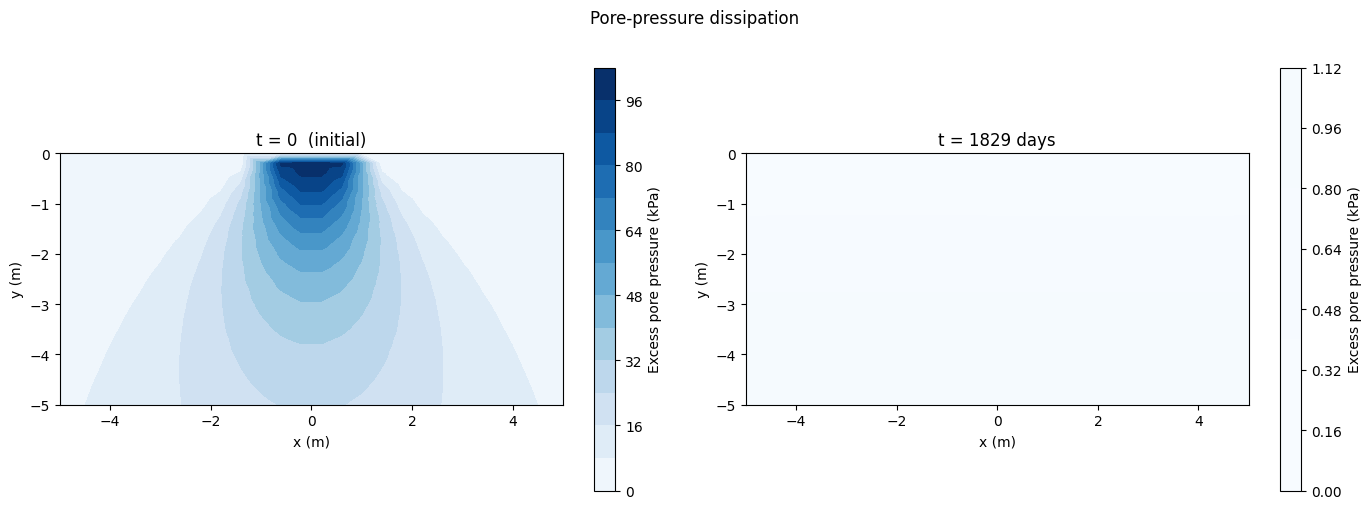

In [4]:
t_mid   = time_steps // 2
triang  = tri.Triangulation(node_X, node_Y)
vmax    = u_hist[0, :].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ti, label in zip(
    axes,
    [0, t_mid],
    ["t = 0  (initial)", f"t = {time_days[t_mid]:.0f} days"]
):
    cf = ax.tricontourf(triang, u_hist[ti, :], levels=15, cmap="Blues", vmin=0, vmax=vmax)
    plt.colorbar(cf, ax=ax, label="Excess pore pressure (kPa)")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(label)
    ax.set_aspect("equal")

plt.suptitle("Pore-pressure dissipation", y=1.01)
plt.tight_layout()
plt.show()

## Surface Settlement Profile

Settlement across the surface width at several times.


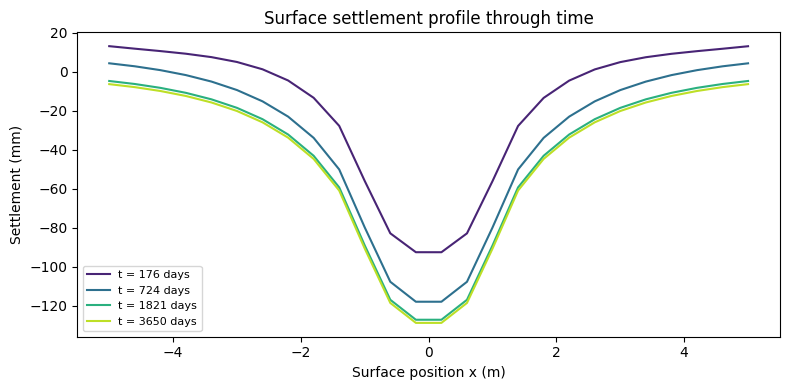

In [5]:
fracs   = [0.05, 0.2, 0.5, 1.0]
colours = plt.cm.viridis(np.linspace(0.1, 0.9, len(fracs)))

fig, ax = plt.subplots(figsize=(8, 4))
for col, frac in zip(colours, fracs):
    ti    = int(frac * (time_steps - 1))
    label = f"t = {time_days[ti]:.0f} days"
    ax.plot(unique_X, -settlement_surface[ti, :] * 1000, color=col, label=label)

ax.set_xlabel("Surface position x (m)")
ax.set_ylabel("Settlement (mm)")
ax.set_title("Surface settlement profile through time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Note — Layered Cv and Mv

To run a layered 2D case, pass `depths`, `Cv`, and `Mv` as lists. Depths are measured downward from y = 0 and apply uniformly across the full width. Example:

```python
depths = [1.5, 3.0, 5.0]
Cv     = [2e-7, 1e-7, 3e-7]
Mv     = [5e-4, 8e-4, 4e-4]

# Permeability per layer
gamma_w = 9.81
k = [Cv_i * Mv_i * gamma_w for Cv_i, Mv_i in zip(Cv, Mv)]
for i, (Cv_i, k_i) in enumerate(zip(Cv, k)):
    print(f"Layer {i+1}: Cv = {Cv_i:.2e} m²/s   k = {k_i:.2e} m/s")

settlement_surface, total_settlement, u_hist, unique_X, node_X, node_Y = Get_terzaghi2D_FEA(
    H=H, W=W, nx=nx, load=load,
    final_time=final_time, time_steps=time_steps,
    Cv=Cv, Mv=Mv, base=base, depths=depths
)
```
